# Olist 电商数据探索与清洗

数据来源：Olist Brazilian E-Commerce (Kaggle)
分析日期：2026-03

-了解数据质量、发现脏数据。-

## 1. 环境准备 & 加载数据

In [1]:
import duckdb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

plt.rcParams["font.sans-serif"] = ["SimHei", "Microsoft YaHei", "DejaVu Sans"]
plt.rcParams["axes.unicode_minus"] = False

con = duckdb.connect("smartquery.duckdb")

tables = con.execute("SHOW TABLES").fetchall()
print("数据库中的表：")
for t in tables:
    cnt = con.execute(f"SELECT COUNT(*) FROM {t[0]}").fetchone()[0]
    print(f"  {t[0]}: {cnt:,} 行")

数据库中的表：
  category_translation: 71 行
  customers: 99,441 行
  order_items: 112,650 行
  order_payments: 103,886 行
  order_reviews: 99,224 行
  orders: 99,441 行
  products: 32,951 行
  sellers: 3,095 行
  v_analysis_base: 117,741 行
  v_customer_metrics: 99,441 行
  v_order_delivery: 96,478 行
  v_order_summary: 118,434 行
  v_unique_customers: 96,096 行
  v_valid_orders: 98,207 行


## 2. 各表概览

In [2]:
# customers
print("=== customers ===")
df = con.execute("SELECT * FROM customers LIMIT 5").fetchdf()
display(df)

# orders
print()
print("=== orders (前5行) ===")
df = con.execute("SELECT * FROM orders LIMIT 5").fetchdf()
display(df)

=== customers ===


,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,09790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,01151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,08775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP



=== orders (前5行) ===


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26


In [3]:
# order_items
print("=== order_items ===")
df = con.execute("SELECT * FROM order_items LIMIT 5").fetchdf()
display(df)

# order_payments
print()
print("=== order_payments ===")
df = con.execute("SELECT * FROM order_payments LIMIT 5").fetchdf()
display(df)

=== order_items ===


,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14



=== order_payments ===


,order_id,payment_sequential,payment_type,payment_installments,payment_value
0,b81ef226f3fe1789b1e8b2acac839d17,1,credit_card,8,99.33
1,a9810da82917af2d9aefd1278f1dcfa0,1,credit_card,1,24.39
2,25e8ea4e93396b6fa0d3dd708e76c1bd,1,credit_card,1,65.71
3,ba78997921bbcdc1373bb41e913ab953,1,credit_card,8,107.78
4,42fdf880ba16b47b59251dd489d4441a,1,credit_card,2,128.45


In [4]:
# products
print("=== products ===")
df = con.execute("SELECT * FROM products LIMIT 5").fetchdf()
display(df)

# sellers
print()
print("=== sellers ===")
df = con.execute("SELECT * FROM sellers LIMIT 5").fetchdf()
display(df)

=== products ===


,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40,287,1,225,16,10,14
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44,276,1,1000,30,18,20
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46,250,1,154,18,9,15
3,cef67bcfe19066a932b7673e239eb23d,bebes,27,261,1,371,26,4,26
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,37,402,4,625,20,17,13



=== sellers ===


,seller_id,seller_zip_code_prefix,seller_city,seller_state
0,3442f8959a84dea7ee197c632cb2df15,13023,campinas,SP
1,d1b65fc7debc3361ea86b5f14c68d2e2,13844,mogi guacu,SP
2,ce3ad9de960102d0677a81f5d0bb7b2d,20031,rio de janeiro,RJ
3,c0f3eea2e14555b6faeea3dd58c1b1c3,04195,sao paulo,SP
4,51a04a8a6bdcb23deccc82b0b80742cf,12914,braganca paulista,SP


## 3. 缺失值检查

In [5]:
def check_missing(con, table_name):
    cols = con.execute("SELECT column_name FROM information_schema.columns "
                       "WHERE table_name='" + table_name + "'").fetchdf()
    col_list = cols["column_name"].tolist()
    
    results = []
    for col in col_list:
        total = con.execute(f"SELECT COUNT(*) FROM {table_name}").fetchone()[0]
        non_null = con.execute(f"SELECT COUNT({col}) FROM {table_name}").fetchone()[0]
        missing = total - non_null
        pct = round(missing / total * 100, 2) if total > 0 else 0
        results.append({"table": table_name, "column": col, "missing": missing, "pct": pct})
    
    return pd.DataFrame(results)

all_missing = pd.DataFrame()
for t in ["customers", "orders", "order_items", "order_payments", "products", "sellers"]:
    result = check_missing(con, t)
    all_missing = pd.concat([all_missing, result])

has_missing = all_missing[all_missing["missing"] > 0]
if len(has_missing) > 0:
    print(f"发现 {len(has_missing)} 个列有缺失值：")
    print(has_missing.to_string(index=False))
else:
    print("所有核心表均无缺失值！")

print()
print("=== orders 表时间字段检查 ===")
time_cols = ["order_approved_at", "order_delivered_carrier_date", "order_delivered_customer_date"]
for col in time_cols:
    missing = con.execute(f"SELECT COUNT(*) FROM orders WHERE {col} IS NULL").fetchone()[0]
    total = con.execute("SELECT COUNT(*) FROM orders").fetchone()[0]
    pct = round(missing / total * 100, 2)
    print(f"  {col}: {missing}/{total} 缺失 ({pct}%)")

发现 11 个列有缺失值：
   table                        column  missing  pct
  orders             order_approved_at      160 0.16
  orders  order_delivered_carrier_date     1783 1.79
  orders order_delivered_customer_date     2965 2.98
products         product_category_name      610 1.85
products           product_name_lenght      610 1.85
products    product_description_lenght      610 1.85
products            product_photos_qty      610 1.85
products              product_weight_g        2 0.01
products             product_length_cm        2 0.01
products             product_height_cm        2 0.01
products              product_width_cm        2 0.01

=== orders 表时间字段检查 ===
  order_approved_at: 160/99441 缺失 (0.16%)
  order_delivered_carrier_date: 1783/99441 缺失 (1.79%)
  order_delivered_customer_date: 2965/99441 缺失 (2.98%)


## 4. 重复值检查

In [6]:
# customers
print("=== customers 唯一客户ID ===")
total_cust = con.execute("SELECT COUNT(*) FROM customers").fetchone()[0]
unique_cust = con.execute("SELECT COUNT(DISTINCT customer_unique_id) FROM customers").fetchone()[0]
print(f"  总行数: {total_cust:,}")
print(f"  唯一客户: {unique_cust:,}")
print(f"  重复行: {total_cust - unique_cust:,}")

print()
print("=== orders：order_id 是否唯一？ ===")
total_ord = con.execute("SELECT COUNT(*) FROM orders").fetchone()[0]
unique_ord = con.execute("SELECT COUNT(DISTINCT order_id) FROM orders").fetchone()[0]
print(f"  总行数: {total_ord:,}")
print(f"  唯一订单: {unique_ord:,}")

print()
print("=== 客户下单次数分布 ===")
order_cnt = con.execute("""
    SELECT order_count, COUNT(*) as customer_cnt
    FROM (
        SELECT customer_id, COUNT(*) as order_count
        FROM orders
        GROUP BY customer_id
    ) t
    GROUP BY order_count
    ORDER BY order_count
""").fetchdf()
print(order_cnt.head(10).to_string(index=False))
print(f"  最大下单次数: {order_cnt['order_count'].max()}")

=== customers 唯一客户ID ===
  总行数: 99,441
  唯一客户: 96,096
  重复行: 3,345

=== orders：order_id 是否唯一？ ===
  总行数: 99,441
  唯一订单: 99,441

=== 客户下单次数分布 ===
 order_count  customer_cnt
           1         99441
  最大下单次数: 1


## 5. 异常值检查

In [7]:
print("=== 订单状态分布 ===")
status = con.execute("""
    SELECT order_status, COUNT(*) as cnt, 
           ROUND(COUNT(*) * 100.0 / SUM(COUNT(*)) OVER(), 2) as pct
    FROM orders
    GROUP BY order_status
    ORDER BY cnt DESC
""").fetchdf()
print(status.to_string(index=False))

print()
print("=== 价格检查 ===")
zero_price = con.execute("SELECT COUNT(*) FROM order_items WHERE price <= 0").fetchone()[0]
print(f"  price <= 0 的订单行: {zero_price}")
max_price = con.execute("SELECT MAX(price) FROM order_items").fetchone()[0]
print(f"  price 最大值: {max_price:.2f}")

print()
print("=== 评价分数分布 ===")
scores = con.execute("""
    SELECT review_score, COUNT(*) as cnt
    FROM order_reviews
    GROUP BY review_score
    ORDER BY review_score
""").fetchdf()
print(scores.to_string(index=False))

=== 订单状态分布 ===
order_status   cnt   pct
   delivered 96478 97.02
     shipped  1107  1.11
    canceled   625  0.63
 unavailable   609  0.61
    invoiced   314  0.32
  processing   301  0.30
     created     5  0.01
    approved     2  0.00

=== 价格检查 ===
  price <= 0 的订单行: 0
  price 最大值: 6735.00

=== 评价分数分布 ===
 review_score   cnt
            1 11424
            2  3151
            3  8179
            4 19142
            5 57328


## 6. 关键分布可视化

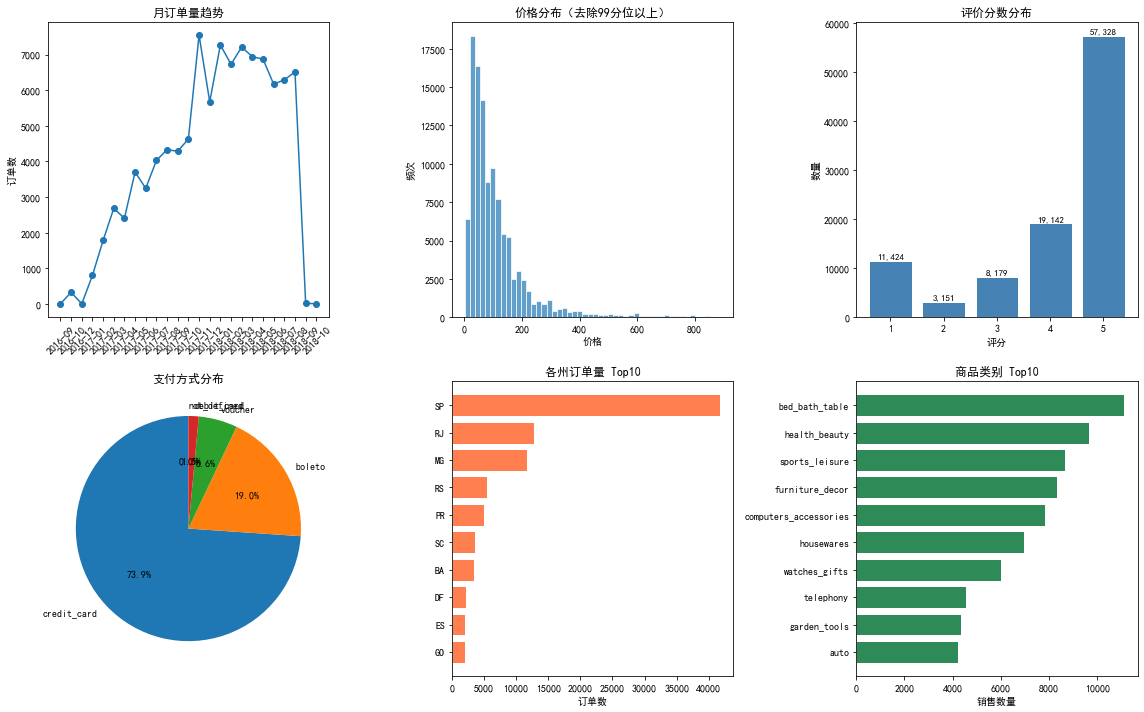

图表已保存到 outputs/eda_distributions.png


In [8]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

# 月订单量趋势
monthly_orders = con.execute("""
    SELECT strftime(order_purchase_timestamp, '%Y-%m') as month,
           COUNT(*) as order_count
    FROM orders
    GROUP BY month
    ORDER BY month
""").fetchdf()
axes[0, 0].plot(monthly_orders["month"].values, monthly_orders["order_count"].values, marker="o", linewidth=1.5)
axes[0, 0].tick_params(axis="x", rotation=45)
axes[0, 0].set_title("月订单量趋势")
axes[0, 0].set_ylabel("订单数")

# 价格分布
prices = con.execute("""
    SELECT price FROM order_items 
    WHERE price > 0 AND price < (SELECT PERCENTILE_CONT(0.99) WITHIN GROUP (ORDER BY price) FROM order_items)
""").fetchdf()
axes[0, 1].hist(prices["price"].values, bins=50, edgecolor="white", alpha=0.7)
axes[0, 1].set_title("价格分布（去除99分位以上）")
axes[0, 1].set_xlabel("价格")
axes[0, 1].set_ylabel("频次")

# 评分分布
scores = con.execute("""
    SELECT review_score, COUNT(*) as cnt
    FROM order_reviews
    GROUP BY review_score
    ORDER BY review_score
""").fetchdf()
axes[0, 2].bar(scores["review_score"].values, scores["cnt"].values, color="steelblue", edgecolor="white")
axes[0, 2].set_title("评价分数分布")
axes[0, 2].set_xlabel("评分")
axes[0, 2].set_ylabel("数量")
for _, row in scores.iterrows():
    axes[0, 2].text(row["review_score"], row["cnt"] + 500, f"{row['cnt']:,}", ha="center", fontsize=9)

# 支付方式分布
payments = con.execute("""
    SELECT payment_type, COUNT(*) as cnt
    FROM order_payments
    GROUP BY payment_type
    ORDER BY cnt DESC
""").fetchdf()
axes[1, 0].pie(payments["cnt"].values, labels=payments["payment_type"].values, autopct="%1.1f%%", startangle=90)
axes[1, 0].set_title("支付方式分布")

# 各州订单量 Top10
state_orders = con.execute("""
    SELECT c.customer_state, COUNT(*) as cnt
    FROM orders o
    JOIN customers c ON o.customer_id = c.customer_id
    GROUP BY c.customer_state
    ORDER BY cnt DESC
    LIMIT 10
""").fetchdf()
axes[1, 1].barh(state_orders["customer_state"].values[::-1], state_orders["cnt"].values[::-1], color="coral", edgecolor="white")
axes[1, 1].set_title("各州订单量 Top10")
axes[1, 1].set_xlabel("订单数")

# 商品类别 Top10
categories = con.execute("""
    SELECT ct.product_category_name_english, COUNT(*) as cnt
    FROM order_items oi
    JOIN products p ON oi.product_id = p.product_id
    JOIN category_translation ct ON p.product_category_name = ct.product_category_name
    GROUP BY ct.product_category_name_english
    ORDER BY cnt DESC
    LIMIT 10
""").fetchdf()
axes[1, 2].barh(categories["product_category_name_english"].values[::-1], categories["cnt"].values[::-1], color="seagreen", edgecolor="white")
axes[1, 2].set_title("商品类别 Top10")
axes[1, 2].set_xlabel("销售数量")

plt.tight_layout()
plt.savefig("outputs/eda_distributions.png", dpi=150, bbox_inches="tight")
plt.show()
print("图表已保存到 outputs/eda_distributions.png")

## 7. 时间范围确认

In [12]:
time_range = con.execute("""
    SELECT MIN(order_purchase_timestamp) as first_order,
           MAX(order_purchase_timestamp) as last_order,
           DATEDIFF('day', MIN(order_purchase_timestamp), MAX(order_purchase_timestamp)) as days_span
    FROM orders
""").fetchdf()
print(f"首单日期: {time_range['first_order'][0]}")
print(f"末单日期: {time_range['last_order'][0]}")
print(f"覆盖天数: {time_range['days_span'][0]} 天")

首单日期: 2016-09-04 21:15:19
末单日期: 2018-10-17 17:30:18
覆盖天数: 773 天


## 8. 表关系验证

In [9]:
print("=== 外键完整性检查 ===")

items_orphan = con.execute("""
    SELECT COUNT(DISTINCT oi.order_id) 
    FROM order_items oi
    LEFT JOIN orders o ON oi.order_id = o.order_id
    WHERE o.order_id IS NULL
""").fetchone()[0]
print(f"  order_items → orders 找不到的ID: {items_orphan}")

pay_orphan = con.execute("""
    SELECT COUNT(DISTINCT op.order_id)
    FROM order_payments op
    LEFT JOIN orders o ON op.order_id = o.order_id
    WHERE o.order_id IS NULL
""").fetchone()[0]
print(f"  order_payments → orders 找不到的ID: {pay_orphan}")

prod_orphan = con.execute("""
    SELECT COUNT(DISTINCT oi.product_id)
    FROM order_items oi
    LEFT JOIN products p ON oi.product_id = p.product_id
    WHERE p.product_id IS NULL
""").fetchone()[0]
print(f"  order_items → products 找不到的ID: {prod_orphan}")

cust_orphan = con.execute("""
    SELECT COUNT(DISTINCT o.customer_id)
    FROM orders o
    LEFT JOIN customers c ON o.customer_id = c.customer_id
    WHERE c.customer_id IS NULL
""").fetchone()[0]
print(f"  orders → customers 找不到的ID: {cust_orphan}")

if items_orphan + pay_orphan + prod_orphan + cust_orphan == 0:
    print("\n[OK] 所有外键关系完整，数据质量良好！")
else:
    print("\n[WARN] 存在孤立记录，需进一步排查")

=== 外键完整性检查 ===
  order_items → orders 找不到的ID: 0
  order_payments → orders 找不到的ID: 0
  order_items → products 找不到的ID: 0
  orders → customers 找不到的ID: 0

[OK] 所有外键关系完整，数据质量良好！


## 9. 数据清洗决策

In [ ]:
print("=== 清洗决策清单 ===")
print()
print("1. orders 表的送达时间缺失")
print("   - 原因：部分订单未送达（canceled/unavailable）")
print("   - 处理：计算送达率时排除这些订单")
print()
print("2. 重复 customer_unique_id")
print("   - 原因：同一用户在不同地址下单")
print("   - 处理：计算唯一用户时用 customer_unique_id 去重")
print()
print("3. 异常价格/运费")
print("   - 处理：保留数据，分析时注明")
print()
print("4. 评价分数两极分化")
print("   - 观察：评分集中在1分和5分")
print("   - 处理：分析时注意分布特征")
print()
print("5. 未完成订单（canceled/unavailable）")
print("   - 处理：漏斗分析中单独统计")

## 10. 数据质量总结

In [10]:
print("=== Olist 数据质量总结 ===\n")
print("[OK] 核心表完整性：")
print("     - 外键关系全部完整，无孤立记录")
print("     - customer_id, order_id, product_id 均能对应\n")
print("[OK] 数据量：")
print("     - 约10万订单、11万商品明细、9.9万客户")
print("     - 覆盖 2016年9月 ~ 2018年10月（约25个月）\n")
print("[WARN] 需注意的点：")
print("     - 送达时间存在缺失（未送达订单）")
print("     - 评分呈U型分布（两极分化）")
print("     - 各州订单量极不均衡（SP占40%+）\n")

con.close()
print("数据库连接已关闭")

=== Olist 数据质量总结 ===

[OK] 核心表完整性：
     - 外键关系全部完整，无孤立记录
     - customer_id, order_id, product_id 均能对应

[OK] 数据量：
     - 约10万订单、11万商品明细、9.9万客户
     - 覆盖 2016年9月 ~ 2018年10月（约25个月）

[WARN] 需注意的点：
     - 送达时间存在缺失（未送达订单）
     - 评分呈U型分布（两极分化）
     - 各州订单量极不均衡（SP占40%+）

数据库连接已关闭
